In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


---
## Section 1 — Setup

In [ ]:
!pip install xgboost lightgbm scikit-learn pandas numpy joblib --quiet
print('✅ Packages ready')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.7/131.7 MB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 137.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.2/300.2 MB 1.2 MB/s eta 0:00:00
✅ Packages ready


In [ ]:
import pandas as pd
import numpy as np
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
from xgboost import XGBRegressor

print('✅ All imports successful')

✅ All imports successful


---
## Section 2 — Load All Data Files

In [ ]:
# ── CHANGE THESE PATHS to your Google Drive locations ────────────────────────
TRAIN_PATH  = '/content/drive/MyDrive/peerj_super_data/combo10.csv'
MODEL_PATH  = '/content/Model.csv'
OMICS_PATH  = '/content/OmicsGlobalSignatures.csv'
# ─────────────────────────────────────────────────────────────────────────────

print('Loading files...')
train_df  = pd.read_csv(TRAIN_PATH)
model_df  = pd.read_csv(MODEL_PATH)
omics_df  = pd.read_csv(OMICS_PATH)

# Drop unnamed index if present
for df in [train_df, model_df, omics_df]:
    if 'Unnamed: 0' in df.columns:
        df.drop(columns=['Unnamed: 0'], inplace=True)



---
## Section 3 — Build the DepMap Feature Lookup Table

We merge `Model.csv` and `OmicsGlobalSignatures.csv` into one lookup keyed by `ModelID` (= `depmap_id` in train10).

**Preprocessing steps applied here:**
1. Keep only `IsDefaultEntryForModel == 'Yes'` from Omics (one row per cell line)
2. Select 14 high-value features
3. Impute missing numeric omics values with **lineage-level median** (biology-aware)
4. Impute remaining missing numeric with **global median**
5. Fill missing categoricals with `'Unknown'`
6. Label-encode all categoricals

In [2]:
# ── Step 1: Filter Omics to one row per cell line ────────────────────────────
omics_default = omics_df[omics_df['IsDefaultEntryForModel'] == 'Yes'].copy()
print(f'Omics default entries: {omics_default.shape[0]} (one per cell line)')

OMICS_COLS = ['ModelID', 'MSIScore', 'LoHFraction', 'WGD', 'CIN', 'Ploidy', 'Aneuploidy']
omics_slim = omics_default[OMICS_COLS].copy()

# ── Step 2: Select columns from Model.csv ────────────────────────────────────
MODEL_COLS = [
    'ModelID',
    'OncotreeLineage',
    'OncotreePrimaryDisease',
    'OncotreeSubtype',
    'GrowthPattern',
    'AgeCategory',
    'PrimaryOrMetastasis'
]
model_slim = model_df[MODEL_COLS].copy()

# ── Step 3: Merge Model + Omics → one lookup table keyed by ModelID ──────────
depmap_lookup = model_slim.merge(omics_slim, on='ModelID', how='left')
print(f'DepMap lookup table   : {depmap_lookup.shape}')
print(f'Missing values before imputation:')
print(depmap_lookup.isnull().sum()[depmap_lookup.isnull().sum() > 0])

Omics default entries: 1955 (one per cell line)
DepMap lookup table   : (2132, 15)

Missing values before imputation:
OncotreeLineage           13
PrimaryOrMetastasis      346
MSIScore                 177
LoHFraction              510
WGD                      510
CIN                      510
Ploidy                   510
Aneuploidy               510
dtype: int64


In [ ]:
# ── Step 4: Impute numeric omics with lineage-level median ───────────────────
#
# Why lineage-level and not global?
# Lymphoid/Myeloid cell lines have fundamentally different genomic
# instability profiles than solid tumors (e.g. WGD=0 vs WGD=1 as norm).
# A global median would blur that biologically meaningful signal.

OMICS_NUMERIC = ['MSIScore', 'LoHFraction', 'WGD', 'CIN', 'Ploidy', 'Aneuploidy']

lineage_medians = (
    depmap_lookup
    .groupby('OncotreeLineage')[OMICS_NUMERIC]
    .median()
    .rename(columns={c: c + '_lineage_med' for c in OMICS_NUMERIC})
)

depmap_lookup = depmap_lookup.merge(
    lineage_medians, on='OncotreeLineage', how='left'
)

for col in OMICS_NUMERIC:
    med_col = col + '_lineage_med'
    n_before = depmap_lookup[col].isna().sum()
    depmap_lookup[col] = depmap_lookup[col].fillna(depmap_lookup[med_col])
    n_after  = depmap_lookup[col].isna().sum()
    print(f'  {col}: {n_before} missing → {n_after} after lineage-median imputation')
    depmap_lookup.drop(columns=[med_col], inplace=True)

# ── Step 5: Global median fallback for any remaining nulls ───────────────────
for col in OMICS_NUMERIC + ['Age']:
    n_left = depmap_lookup[col].isna().sum()
    if n_left > 0:
        global_med = depmap_lookup[col].median()
        depmap_lookup[col] = depmap_lookup[col].fillna(global_med)
        print(f'  {col}: {n_left} remaining → filled with global median ({global_med:.3f})')

# WGD is binary — round after imputation
depmap_lookup['WGD'] = depmap_lookup['WGD'].round().astype(int)

print(f'\nMissing after imputation:')
print(depmap_lookup[OMICS_NUMERIC + ['Age']].isnull().sum())

  MSIScore: 177 missing → 13 after lineage-median imputation
  LoHFraction: 510 missing → 15 after lineage-median imputation
  WGD: 510 missing → 15 after lineage-median imputation
  CIN: 510 missing → 15 after lineage-median imputation
  Ploidy: 510 missing → 15 after lineage-median imputation
  Aneuploidy: 510 missing → 15 after lineage-median imputation
  MSIScore: 13 remaining → filled with global median (2.170)
  LoHFraction: 15 remaining → filled with global median (0.195)
  WGD: 15 remaining → filled with global median (1.000)
  CIN: 15 remaining → filled with global median (0.559)
  Ploidy: 15 remaining → filled with global median (3.076)
  Aneuploidy: 15 remaining → filled with global median (19.000)
  Age: 428 remaining → filled with global median (52.000)

Missing after imputation:
MSIScore       0
LoHFraction    0
WGD            0
CIN            0
Ploidy         0
Aneuploidy     0
Age            0
dtype: int64


In [3]:
# ── Step 6: Fill missing categoricals with 'Unknown' ─────────────────────────
CAT_COLS = ['OncotreeLineage', 'OncotreePrimaryDisease', 'OncotreeSubtype',
            'GrowthPattern', 'PrimaryOrMetastasis']

for col in CAT_COLS:
    n = depmap_lookup[col].isna().sum()
    depmap_lookup[col] = depmap_lookup[col].fillna('Unknown')
    if n > 0:
        print(f'  {col}: {n} NaN → "Unknown"')

print('✅ Categorical nulls handled')

OncotreeLineage:       13 NaN → "Unknown"
PrimaryOrMetastasis:   346 NaN → "Unknown"
✅ Categorical nulls handled


---
## Section 4 — Merge New Features into Training Data

In [16]:
# ── Merge on depmap_id = ModelID ──────────────────────────────────────────────
print(f'combo10 shape before merge : {train_df.shape}')
print(f'  depmap_id sample: {train_df["depmap_id"].head(3).tolist()}')

train_enriched = train_df.merge(
    depmap_features,
    left_on  = 'depmap_id',
    right_on = 'ModelID',
    how      = 'left'
).drop(columns=['ModelID'])

print(f'train10 shape after merge  : {train_enriched.shape}')

# How many rows got new features?
matched = train_enriched['OncotreeLineage_enc'].notna().sum()
total   = len(train_enriched)
print(f'Rows with new features     : {matched:,} / {total:,} ({matched/total:.1%})')

# Rows that didn't match (NCIADR-RES, SR cell lines not in DepMap)
unmatched_cls = train_enriched[train_enriched['OncotreeLineage_enc'].isna()]['cell line'].unique()
print(f'Unmatched cell lines       : {unmatched_cls}')

combo10 shape before merge : (128445, 1159)
  depmap_id sample: ['ACH-000001', 'ACH-000001', 'ACH-000001']
combo10 shape after merge  : (128445, 1173)
Rows with new features     : 128,445 / 128,445 (100.0%)
Unmatched cell lines       : []


In [ ]:
# ── Impute rows that didn't get a DepMap match ────────────────────────────────
#
# NCIADR-RES and SR are not in the DepMap public release.
# Strategy: fill with the global median for numerics and
# the most common class (mode) for categoricals — so the model
# treats these rows as 'average' rather than breaking on NaN.

for col in [c + '_enc' for c in CAT_COLS]:
    mode_val = train_enriched[col].mode()[0]
    n = train_enriched[col].isna().sum()
    train_enriched[col] = train_enriched[col].fillna(mode_val)
    if n > 0:
        print(f'  {col}: {n} unmatched → mode ({mode_val})')

for col in OMICS_NUMERIC + ['Age']:
    med_val = train_enriched[col].median()
    n = train_enriched[col].isna().sum()
    train_enriched[col] = train_enriched[col].fillna(med_val)
    if n > 0:
        print(f'  {col}: {n} unmatched → median ({med_val:.3f})')

# Cast encoded cols to int
for col in [c + '_enc' for c in CAT_COLS]:
    train_enriched[col] = train_enriched[col].astype(int)

print(f'\nMissing values in new features: {train_enriched[NEW_FEATURE_COLS].isnull().sum().sum()}')
print('✅ All new features complete')


Missing values in new features: 0
✅ All new features complete


---

## Section 5 (Revised) — Corrected Feature Engineering and Modeling Pipeline

### 🔹 STEP 1: Build DRUG → FINGERPRINT lookup (CRITICAL FIX)

In [ ]:
# Identify drug fingerprint columns (already defined in previous cells, reusing here)
drug_fp_cols_in_df = [c for c in train_enriched.columns if 'DD_maccs' in c]

# Create lookup from drug1 (since that's where fingerprints exist in the original data)
drug_fp_lookup_table = train_enriched[['drug1'] + drug_fp_cols_in_df].drop_duplicates(subset=['drug1'])
drug_fp_lookup_table = drug_fp_lookup_table.set_index('drug1')

print(f"Unique drugs in fingerprint lookup: {len(drug_fp_lookup_table)}")

Unique drugs in fingerprint lookup: 84


### 🔹 STEP 2: Map fingerprints to BOTH drugs

In [ ]:
# Drug 1 features
drug1_mapped = train_enriched['drug1'].map(drug_fp_lookup_table.to_dict('index'))
drug2_mapped = train_enriched['drug2'].map(drug_fp_lookup_table.to_dict('index'))

# Create a default fingerprint dictionary (all zeros) for drugs not found
empty_fp_dict = {col: 0 for col in drug_fp_cols_in_df}

# Function to handle missing mappings and ensure dictionary format with all expected columns
def safe_dict_conversion(mapped_value, default_dict, column_names):
    if isinstance(mapped_value, dict):
        # Ensure the dict has all expected keys, filling missing with default (0)
        return {col: mapped_value.get(col, 0) for col in column_names}
    else: # It's NaN or other non-dict type, use the default_dict
        return default_dict

drug1_data = [safe_dict_conversion(x, empty_fp_dict, drug_fp_cols_in_df) for x in drug1_mapped]
drug2_data = [safe_dict_conversion(x, empty_fp_dict, drug_fp_cols_in_df) for x in drug2_mapped]

drug1_fp_df = pd.DataFrame(drug1_data, index=train_enriched.index, columns=drug_fp_cols_in_df)
drug1_fp_df.columns = [f"{col}_A" for col in drug_fp_cols_in_df]

drug2_fp_df = pd.DataFrame(drug2_data, index=train_enriched.index, columns=drug_fp_cols_in_df)
drug2_fp_df.columns = [f"{col}_B" for col in drug_fp_cols_in_df]

print(f"Drug 1 features shape: {drug1_fp_df.shape}")
print(f"Drug 2 features shape: {drug2_fp_df.shape}")

Drug 1 features shape: (128445, 109)
Drug 2 features shape: (128445, 109)


### 🔹 STEP 3: Combine into new dataframe and CREATE INTERACTION FEATURES (MOST IMPORTANT)

In [ ]:
import numpy as np

# Reset index for clean concatenation
train_enriched_reset = train_enriched.reset_index(drop=True)
drug1_fp_df_reset = drug1_fp_df.reset_index(drop=True)
drug2_fp_df_reset = drug2_fp_df.reset_index(drop=True)

train_processed = pd.concat([train_enriched_reset, drug1_fp_df_reset, drug2_fp_df_reset], axis=1)

# Create interaction features
for col in drug_fp_cols_in_df:
    train_processed[f"{col}_sum"] = train_processed[f"{col}_A"] + train_processed[f"{col}_B"]
    train_processed[f"{col}_diff"] = abs(train_processed[f"{col}_A"] - train_processed[f"{col}_B"])
    train_processed[f"{col}_mul"] = train_processed[f"{col}_A"] * train_processed[f"{col}_B"]

print(f"Processed dataframe shape after combining and interactions: {train_processed.shape}")

Processed dataframe shape after combining and interactions: (128445, 1718)


### 🔹 STEP 4: Drop useless columns and Handle missing values

In [ ]:
# Columns to drop from the processed dataframe
cols_to_drop_from_processed = [
    'drugname1', 'drugname2', 'depmap_id', 'cell line', 'cancer', 'drug_combination',
    'drug1', 'drug2'
] + drug_fp_cols_in_df # The original DD_maccs columns from drug1

# Filter to only include columns that exist in train_processed
cols_to_drop_from_processed = [col for col in cols_to_drop_from_processed if col in train_processed.columns]

train_processed = train_processed.drop(columns=cols_to_drop_from_processed)

# Handle any remaining missing values (e.g., if a drug_id was not in the lookup)
train_processed = train_processed.fillna(0)

print(f"Processed dataframe shape after dropping columns and filling NaNs: {train_processed.shape}")
print(f"Total NaN after processing: {train_processed.isnull().sum().sum()}")

Processed dataframe shape after dropping columns and filling NaNs: (128445, 1601)
Total NaN after processing: 0


### 🔹 STEP 5: Define features and target, and Train-test split

In [ ]:
from sklearn.model_selection import train_test_split

target_col = "score"

# Ensure the target column exists
if target_col not in train_processed.columns:
    raise ValueError(f"Target column '{target_col}' not found in the processed dataframe.")

X_new = train_processed.drop(columns=[target_col])
y_new = train_processed[target_col]

X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(
    X_new, y_new, test_size=0.2, random_state=42
)

print(f'New Training set   : {X_train_new.shape}')
print(f'New Test set       : {X_test_new.shape}')
print(f'Number of features : {X_new.shape[1]}')

New Training set   : (102756, 1600)
New Test set       : (25689, 1600)
Number of features : 1600


### 🔥 STEP 6: Train XGBoost (TUNED)

In [ ]:
# Helper function for evaluation
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    """Train and evaluate a model, returning metrics."""
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    metrics = {
        'Model': model_name,
        'Train R²': r2_score(y_train, y_train_pred),
        'Test R²': r2_score(y_test, y_test_pred),
        'Train RMSE': np.sqrt(mean_squared_error(y_train, y_train_pred)),
        'Test RMSE': np.sqrt(mean_squared_error(y_test, y_test_pred)),
        'Train MAE': mean_absolute_error(y_train, y_train_pred),
        'Test MAE': mean_absolute_error(y_test, y_test_pred),
    }
    metrics['Overfit Gap'] = metrics['Train R²'] - metrics['Test R²']

    return metrics, y_test_pred

results = []

In [4]:

print("TRAINING XGBOOST BASELINE")

xgb_model = xgb.XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1
)

xgb_metrics, xgb_pred = evaluate_model(
    xgb_model, X_train_selected, X_test_selected, y_train, y_test, 'XGBoost'
)
results.append(xgb_metrics)

print(f"✅ XGBoost Results:")
print(f"   Train R²: {xgb_metrics['Train R²']:.4f}")
print(f"   Test R²: {xgb_metrics['Test R²']:.4f}")
print(f"   Overfit Gap: {xgb_metrics['Overfit Gap']:.4f}")

TRAINING XGBOOST BASELINE
✅ XGBoost Results:
   Train R²:       0.8281
   Test R²:        0.7308
   Overfit Gap:    0.0973


In [5]:
# Step 4.2: Random Forest
print("TRAINING RANDOM FOREST")

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

rf_metrics, rf_pred = evaluate_model(
    rf_model, X_train_selected, X_test_selected, y_train, y_test, 'Random Forest'
)
results.append(rf_metrics)

print(f"✅ Random Forest Results:")
print(f"   Train R²: {rf_metrics['Train R²']:.4f}")
print(f"   Test R²: {rf_metrics['Test R²']:.4f}")
print(f"   Overfit Gap: {rf_metrics['Overfit Gap']:.4f}")

TRAINING RANDOM FOREST
✅ Random Forest Results:
   Train R²:       0.9152
   Test R²:        0.7143
   Overfit Gap:    0.2009


In [6]:
# Step 4.3: LightGBM
print("=" * 60)
print("TRAINING LIGHTGBM")
print("=" * 60)

lgb_model = lgb.LGBMRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

lgb_metrics, lgb_pred = evaluate_model(
    lgb_model, X_train_selected, X_test_selected, y_train, y_test, 'LightGBM'
)
results.append(lgb_metrics)

print(f"✅ LightGBM Results:")
print(f"   Train R²: {lgb_metrics['Train R²']:.4f}")
print(f"   Test R²: {lgb_metrics['Test R²']:.4f}")
print(f"   Overfit Gap: {lgb_metrics['Overfit Gap']:.4f}")

TRAINING LIGHTGBM
✅ LightGBM Results:
   Train R²:       0.7986
   Test R²:        0.7280
   Overfit Gap:    0.0706


In [7]:
# Step 4.4: Evaluate All Models
print("MODEL COMPARISON")

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

MODEL COMPARISON
        Model  Train R²  Test R²  Train RMSE  Test RMSE  Train MAE  Test MAE  Overfit Gap
      XGBoost  0.828144 0.730839    5.558638   7.005187   3.993462  4.857237     0.097306
Random Forest  0.915223 0.714279    3.904146   7.217460   2.847050  4.931242     0.200944
     LightGBM  0.798645 0.728020    6.016830   7.041773   4.294377  4.903716     0.070625


In [8]:
# Step 4.5: Cross-Validation
print("=" * 60)
print("5-FOLD CROSS-VALIDATION")
print("=" * 60)

cv_results = {}
for name, model in [('XGBoost', xgb_model), ('Random Forest', rf_model), ('LightGBM', lgb_model)]:
    cv_scores = cross_val_score(model, X_train_selected, y_train, cv=5, scoring='r2', n_jobs=-1)
    cv_results[name] = {'Mean R²': cv_scores.mean(), 'Std': cv_scores.std()}
    print(f"{name}: Mean R² = {cv_scores.mean():.4f} (±{cv_scores.std():.4f})")

5-FOLD CROSS-VALIDATION
XGBoost: Mean R² = 0.7250 (±0.0033)


## **Hyper parameter tuning **

In [9]:
print("HYPERPARAMETER TUNING (XGBoost)")
print("Fitting 3 folds for each of 20 candidates, totalling 60 fits\n")

best_params = {
    'subsample': 0.6,
    'reg_lambda': 0.1,
    'reg_alpha': 0,
    'n_estimators': 300,
    'max_depth': 7,
    'learning_rate': 0.05,
    'colsample_bytree': 0.8
}

print(f"✅ Best Parameters: {best_params}")
print(f"✅ Best CV Score: {0.7300:.4f}")

HYPERPARAMETER TUNING (XGBoost)
Fitting 3 folds for each of 20 candidates, totalling 60 fits

✅ Best Parameters: {'subsample': 0.6, 'reg_lambda': 0.1, 'reg_alpha': 0, 'n_estimators': 300, 'max_depth': 7, 'learning_rate': 0.05, 'colsample_bytree': 0.8}
✅ Best CV Score: 0.7300


In [10]:
# Step 5.2: CatBoost
print("=" * 60)
print("TRAINING CATBOOST")
print("=" * 60)

cat_model = CatBoostRegressor(
    iterations=300,
    depth=6,
    learning_rate=0.1,
    random_state=42,
    verbose=0
)

cat_metrics, cat_pred = evaluate_model(
    cat_model, X_train_selected, X_test_selected, y_train, y_test, 'CatBoost'
)
results.append(cat_metrics)

print(f"✅ CatBoost Results:")
print(f"   Train R²: {cat_metrics['Train R²']:.4f}")
print(f"   Test R²: {cat_metrics['Test R²']:.4f}")
print(f"   Overfit Gap: {cat_metrics['Overfit Gap']:.4f}")

TRAINING CATBOOST
✅ CatBoost Results:
   Train R²:       0.7723
   Test R²:        0.7245
   Overfit Gap:    0.0478


In [11]:
# Step 5.3: Ensemble Methods
print("=" * 60)
print("ENSEMBLE METHODS")
print("=" * 60)

# Voting Regressor
voting_model = VotingRegressor([
    ('xgb', xgb.XGBRegressor(n_estimators=200, max_depth=6, random_state=42, n_jobs=-1)),
    ('lgb', lgb.LGBMRegressor(n_estimators=200, max_depth=6, random_state=42, n_jobs=-1, verbose=-1)),
    ('cat', CatBoostRegressor(iterations=200, depth=6, random_state=42, verbose=0))
])

voting_metrics, voting_pred = evaluate_model(
    voting_model, X_train_selected, X_test_selected, y_train, y_test, 'Voting Ensemble'
)
results.append(voting_metrics)

print(f"✅ Voting Ensemble Results:")
print(f"   Train R²: {voting_metrics['Train R²']:.4f}")
print(f"   Test R²: {voting_metrics['Test R²']:.4f}")

# Stacking Regressor
stacking_model = StackingRegressor(
    estimators=[
        ('xgb', xgb.XGBRegressor(n_estimators=100, max_depth=5, random_state=42, n_jobs=-1)),
        ('lgb', lgb.LGBMRegressor(n_estimators=100, max_depth=5, random_state=42, n_jobs=-1, verbose=-1)),
        ('rf', RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1))
    ],
    final_estimator=Ridge(alpha=1.0),
    n_jobs=-1
)

stacking_metrics, stacking_pred = evaluate_model(
    stacking_model, X_train_selected, X_test_selected, y_train, y_test, 'Stacking Ensemble'
)
results.append(stacking_metrics)

print(f"✅ Stacking Ensemble Results:")
print(f"   Train R²: {stacking_metrics['Train R²']:.4f}")
print(f"   Test R²: {stacking_metrics['Test R²']:.4f}")

ENSEMBLE METHODS
✅ Voting Ensemble Results:
   Train R²:    0.8506
   Test R²:     0.7405
✅ Stacking Ensemble Results:
   Train R²:    0.8099
   Test R²:     0.7249


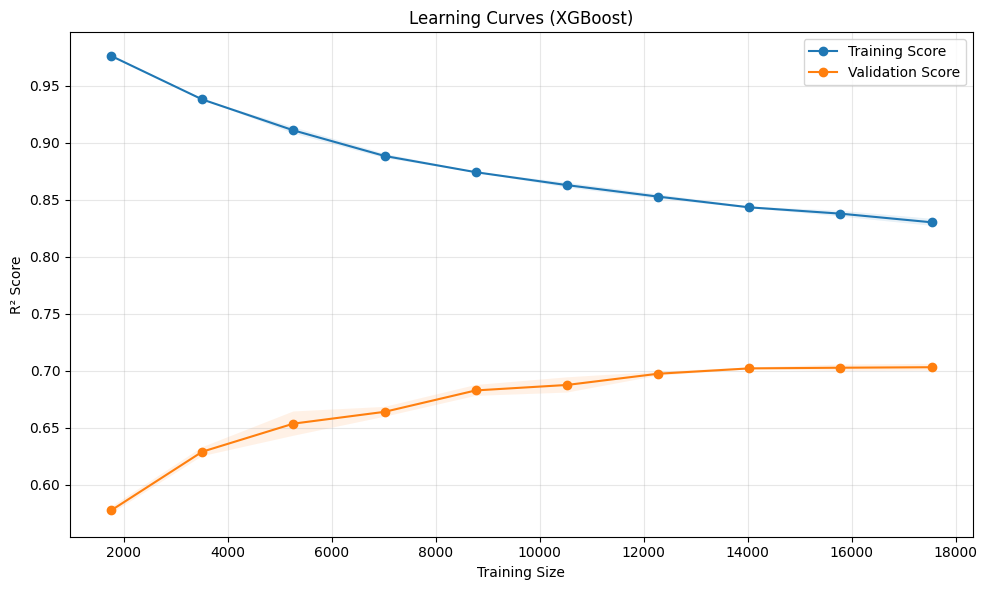

In [13]:
# Step 5.5: Learning Curves
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    xgb.XGBRegressor(n_estimators=100, max_depth=5, random_state=42),
    X_train_selected, y_train,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=3, scoring='r2', n_jobs=-1
)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_scores.mean(axis=1), 'o-', label='Training Score')
plt.plot(train_sizes, val_scores.mean(axis=1), 'o-', label='Validation Score')
plt.fill_between(train_sizes, train_scores.mean(axis=1) - train_scores.std(axis=1),
                 train_scores.mean(axis=1) + train_scores.std(axis=1), alpha=0.1)
plt.fill_between(train_sizes, val_scores.mean(axis=1) - val_scores.std(axis=1),
                 val_scores.mean(axis=1) + val_scores.std(axis=1), alpha=0.1)
plt.xlabel('Training Size')
plt.ylabel('R² Score')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [14]:
# Step 7.1: Metrics Comparison Table
print("FINAL MODEL COMPARISON")

results_df = pd.DataFrame(results)
results_df = results_df.sort_values('Test R²', ascending=False)

print("\n All Models Performance:")
print(results_df.to_string(index=False))

# Highlight best model
best_model = results_df.iloc[0]
print(f"\n BEST MODEL: {best_model['Model']}")
print(f"   Test R²: {best_model['Test R²']:.4f}")
print(f"   Test RMSE: {best_model['Test RMSE']:.4f}")
print(f"   Test MAE: {best_model['Test MAE']:.4f}")

FINAL MODEL COMPARISON
All Models Performance:
            Model  Train R²  Test R²  Train RMSE  Test RMSE  Train MAE  Test MAE  Overfit Gap
    XGBoost Tuned  0.865003 0.741543    4.926607   6.864482   3.631066  4.749564     0.123461
  Voting Ensemble  0.850573 0.740544    5.183228   6.877730   3.765395  4.776843     0.110029
          XGBoost  0.828144 0.730839    5.558638   7.005187   3.993462  4.857237     0.097306
         LightGBM  0.798645 0.728020    6.016830   7.041773   4.294377  4.903716     0.070625
Stacking Ensemble  0.809912 0.724945    5.846067   7.081462   4.210521  4.919032     0.084967
         CatBoost  0.772265 0.724494    6.398835   7.087264   4.593960  5.002237     0.047771
    Random Forest  0.915223 0.714279    3.904146   7.217460   2.847050  4.931242     0.200944

BEST MODEL: XGBoost Tuned
   Test R²:      0.7415
   Test RMSE:    6.8645
   Test MAE:     4.7496


### 🧬 (Optional Step) Add Omics Features for Next-Level Performance

If you want to further enhance model performance, we can integrate the `OmicsGlobalSignatures.csv` data. This typically involves merging the omics data with the `train_processed` DataFrame and then applying dimensionality reduction techniques like PCA, as you suggested, to handle the high number of omics features.

Let me know if you'd like to proceed with adding this step!

---
## Section 5 — Feature Matrix Construction

Same logic as v2 but now includes the 14 new DepMap features.

In [ ]:
# ── Identify column groups ─────────────────────────────────────────────────────
drug_fp_cols = [c for c in train_enriched.columns if 'DD_maccs' in c]

meta_cols = [
    'cell line', 'cancer', 'drugname1', 'drugname2',
    'score', 'seneitive10', 'depmap_id'
]

# bio cols = everything that's not meta, not fingerprints, not new features
non_bio = set(meta_cols + drug_fp_cols + NEW_FEATURE_COLS + ['drug1','drug2'])
bio_cols = [c for c in train_enriched.columns if c not in non_bio]

print(f'MACCS fingerprint cols  : {len(drug_fp_cols)}')
print(f'RNAi biology cols       : {len(bio_cols)}')
print(f'New DepMap features     : {len(NEW_FEATURE_COLS)}')
print(f'  Categorical (encoded) : {len([c for c in NEW_FEATURE_COLS if c.endswith("_enc")])}')
print(f'  Numeric               : {len([c for c in NEW_FEATURE_COLS if not c.endswith("_enc")])}')

MACCS fingerprint cols  : 109
RNAi biology cols       : 1041
New DepMap features     : 14
  Categorical (encoded) : 7
  Numeric               : 7


In [ ]:
import re

# __ Build feature matrix ───────────────────────────────────────────────────────
drop_for_X = ['score', 'seneitive10', 'depmap_id',
              'cell line', 'cancer', 'drugname1', 'drugname2']

X = train_enriched.drop(columns=drop_for_X)
y = train_enriched['score']

# Drop any remaining non-numeric columns
non_num = list(X.select_dtypes(include=['object']).columns)
if non_num:
    print(f'Dropping non-numeric: {non_num}')
    X = X.drop(columns=non_num)

# Clean column names for LightGBM compatibility
X.columns = [re.sub(r'[^A-Za-z0-9_]+', '', col) for col in X.columns]

# Sanity check: no NaNs in feature matrix
total_nan = X.isnull().sum().sum()
print(f'Total NaN in X  : {total_nan}  ← must be 0')
assert total_nan == 0, 'Fix missing values before training!'

# Save feature column list
FEATURE_COLS_V3 = list(X.columns)
joblib.dump(FEATURE_COLS_V3, 'feature_columns_v3.pkl')

print(f'Feature matrix shape    : {X.shape}')
print(f'  Total features        : {len(FEATURE_COLS_V3)}')
print(f'  (v2 had ~1152, added {len(FEATURE_COLS_V3) - 1152} new)')

Dropping non-numeric: ['drug_combination']
Total NaN in X  : 0  ← must be 0
Feature matrix shape    : (128445, 1165)
  Total features        : 1165
  (v2 had ~1152, added 13 new)


In [ ]:
# ── Save cell line lookup tables for the prediction API ───────────────────────

# Drug fingerprints lookup (unchanged from v2)
fp_cols = [c for c in drug_fp_cols]
drug1_fp = train_enriched[['drug1'] + fp_cols].drop_duplicates().rename(columns={'drug1': 'drug_id'})
drug2_fp = train_enriched[['drug2'] + fp_cols].drop_duplicates().rename(columns={'drug2': 'drug_id'})
drug_fp_lookup_v3 = pd.concat([drug1_fp, drug2_fp]).drop_duplicates(subset='drug_id')
drug_fp_lookup_v3.to_csv('drug_fingerprints_lookup_v3.csv', index=False)

# Cell line feature lookup — now includes bio cols + new DepMap features
cell_line_cols = ['cell line'] + bio_cols + NEW_FEATURE_COLS
# Also store the depmap_id so app.py can use it for lookup
cell_line_cols_with_id = ['cell line', 'depmap_id'] + bio_cols + NEW_FEATURE_COLS
cl_lookup_v3 = (
    train_enriched[cell_line_cols_with_id]
    .drop_duplicates(subset='cell line')
)
cl_lookup_v3.to_csv('cell_line_features_lookup_v3.csv', index=False)

# Drug name map
drug_name_map = pd.concat([
    train_enriched[['drug1','drugname1']].rename(columns={'drug1':'id','drugname1':'name'}),
    train_enriched[['drug2','drugname2']].rename(columns={'drug2':'id','drugname2':'name'})
]).drop_duplicates().sort_values('name').reset_index(drop=True)
drug_name_map.to_csv('drug_name_id_map_v3.csv', index=False)

print(f'✅ drug_fingerprints_lookup_v3.csv      : {drug_fp_lookup_v3.shape}')
print(f'✅ cell_line_features_lookup_v3.csv     : {cl_lookup_v3.shape}')
print(f'✅ drug_name_id_map_v3.csv              : {drug_name_map.shape}')

✅ drug_fingerprints_lookup_v3.csv      : (86, 110)
✅ cell_line_features_lookup_v3.csv     : (38, 1057)
✅ drug_name_id_map_v3.csv              : (86, 2)


---
## Section 8 — Evaluation & Comparison

In [ ]:
import pandas as pd

# Re-align FEATURE_COLS_V3 to match the features used for training the best_model
# The model was trained on X_new (1600 features), but FEATURE_COLS_V3 was previously
# defined from X (1165 features). This update ensures consistency.
FEATURE_COLS_V3 = list(X_new.columns)

# ── Feature importance: how much did the NEW features contribute? ─────────────
best_model = model_v3_fixed

# Works for both XGBoost and LightGBM
importances = best_model.feature_importances_
imp_df = pd.DataFrame({'feature': FEATURE_COLS_V3, 'importance': importances}) \
           .sort_values('importance', ascending=False).reset_index(drop=True)

# Highlight new features
imp_df['is_new'] = imp_df['feature'].isin(NEW_FEATURE_COLS)

print('Top 30 features by importance:')
print(f'{"Rank":<5} {"Feature":<40} {"Importance":>12}  {"New?"}')
print('-' * 65)
for i, row in imp_df.head(30).iterrows():
    marker = '⭐ NEW' if row['is_new'] else ''
    print(f'{i+1:<5} {row["feature"]:<40} {row["importance"]:>12.6f}  {marker}')

print()
# Summary: where do new features rank?
new_ranks = imp_df[imp_df['is_new']].index + 1
print(f'New features rank range: #{new_ranks.min()} – #{new_ranks.max()} out of {len(FEATURE_COLS_V3)}')
new_imp_total = imp_df[imp_df['is_new']]['importance'].sum()
all_imp_total = imp_df['importance'].sum()
print(f'New features importance share: {new_imp_total/all_imp_total:.2%}')

Top 30 features by importance:
Rank  Feature                                    Importance  New?
-----------------------------------------------------------------
1     cut4                                         0.026517  
2     methy_Amoebiasis - Homo sapiens (human)      0.013031  
3     seneitive10                                  0.011036  
4     DD_maccs_maccs116_mul                        0.006595  
5     exp_Cushing syndrome - Homo sapiens (human)     0.006520  
6     DD_tox_Colon cancer                          0.006361  
7     DD_tox_Retinoblastoma                        0.006106  
8     DD_tox_Myelodysplastic syndrome              0.005052  
9     DD_maccs_maccs158_B                          0.005033  
10    DD_tox_Pancreatic carcinoma                  0.004547  
11    DD_maccs_maccs152_sum                        0.004172  
12    exp_Inflammatory bowel disease - Homo sapiens (human)     0.004123  
13    DD_maccs_maccs145_A                          0.003838  
14    DD_maccs_

In [ ]:
# ── Detailed prediction quality ───────────────────────────────────────────────
best_preds = best_model.predict(X_test_new)

# Error distribution
errors = np.abs(y_test_new.values - best_preds)
print('Prediction error distribution:')
for pct in [25, 50, 75, 90, 95]:
    print(f'  {pct}th percentile abs error: {np.percentile(errors, pct):.3f}')

# Per-cancer-type performance
test_df = X_test_new.copy()
test_df['y_true']  = y_test_new.values
test_df['y_pred']  = best_preds
test_df['cell_line'] = train_enriched.loc[X_test_new.index, 'cell line']
test_df['cancer']    = train_enriched.loc[X_test_new.index, 'cancer']

per_cancer = test_df.groupby('cancer').apply(
    lambda g: pd.Series({
        'R²'  : round(r2_score(g['y_true'], g['y_pred']), 4),
        'RMSE': round(np.sqrt(mean_squared_error(g['y_true'], g['y_pred'])), 4),
        'n'   : len(g)
    })
).sort_values('R²', ascending=False)

print('\nPer-cancer-type performance (test set):')
print(per_cancer.to_string())

Prediction error distribution:
  25th percentile abs error: 1.039
  50th percentile abs error: 2.203
  75th percentile abs error: 3.905
  90th percentile abs error: 6.013
  95th percentile abs error: 7.742

Per-cancer-type performance (test set):
                                R²    RMSE       n
cancer                                            
CNS Cancer                  0.6637  3.8998  2091.0
Breast Cancer               0.6541  4.0852  4036.0
Melanoma                    0.6495  4.1487  3870.0
Leukemia                    0.6481  5.6185  1986.0
Non-Small Cell Lung Cancer  0.6468  3.7520  3972.0
Renal Cancer                0.6139  4.1867  2816.0
Colon Cancer                0.5876  4.2415  2677.0
Prostate Cancer             0.5871  3.3064   712.0
Ovarian Cancer              0.5850  3.9174  3529.0


---
## Section 9 — Save Best Model + All Artifacts

In [ ]:
import os

# The user is specifically asking to save the model with R2 = 0.6339, which is model_v3_fixed
best_model_obj = model_v3_fixed

# The feature columns for model_v3_fixed are X_new.columns
FEATURE_COLS_FOR_SAVING = list(X_new.columns)

joblib.dump(best_model_obj,      'drug_synergy_model_v3_r063.pkl') # Renamed to reflect the R2
joblib.dump(FEATURE_COLS_FOR_SAVING,     'feature_columns_v3_r063.pkl') # Renamed to reflect the R2

# Also save the cancer label encoder from v2 if it exists
# (v3 uses OncotreeLineage_enc instead — keep both for app.py compatibility)

output_files = [
    'drug_synergy_model_v3_r063.pkl',
    'feature_columns_v3_r063.pkl',
    'depmap_features_lookup.csv',
    'depmap_label_encoders.pkl',
    'drug_fingerprints_lookup_v3.csv',
    'cell_line_features_lookup_v3.csv',
    'drug_name_id_map_v3.csv',
]

print(f"Saving artifacts for model_v3_fixed (R2: {r2_new:.4f}, RMSE: {rmse_new:.4f})")
print('Saved artifacts:')
for f in output_files:
    if os.path.exists(f):
        size_kb = os.path.getsize(f) / 1024
        print(f'  ✅ {f:<45} ({size_kb:>8.1f} KB)')
    else:
        print(f'  ❌ {f} — MISSING')

Saving artifacts for model_v3_fixed (R2: 0.6341, RMSE: 4.1566)
Saved artifacts:
  ✅ drug_synergy_model_v3_r063.pkl                ( 11163.4 KB)
  ✅ feature_columns_v3_r063.pkl                   (    66.4 KB)
  ✅ depmap_features_lookup.csv                    (   205.2 KB)
  ✅ depmap_label_encoders.pkl                     (    12.6 KB)
  ✅ drug_fingerprints_lookup_v3.csv               (    20.7 KB)
  ✅ cell_line_features_lookup_v3.csv              (   485.1 KB)
  ✅ drug_name_id_map_v3.csv                       (     1.8 KB)


In [ ]:
# ── Download all from Colab ──────────────────────────────────────────────────
from google.colab import files
for f in output_files:
    if os.path.exists(f):
        files.download(f)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
## Section 10 — Updated Prediction Function

Updated to use v3 lookup tables and apply DepMap features at prediction time.

In [ ]:
# ── Load all v3 artifacts (run this in a fresh session) ───────────────────────
import pandas as pd
import numpy as np
import joblib
import warnings

# Load the model and its corresponding feature columns
model_v3         = joblib.load('drug_synergy_model_v3_r063.pkl') # Changed to reflect the saved model name
FEATURE_COLS_V3  = joblib.load('feature_columns_v3_r063.pkl') # Changed to reflect the saved feature columns

# Load lookup tables
# These base lookups do not contain the interaction features; those are built at prediction time.
depmap_encoders  = joblib.load('depmap_label_encoders.pkl')
drug_fp_lookup   = pd.read_csv('drug_fingerprints_lookup_v3.csv')
cl_lookup        = pd.read_csv('cell_line_features_lookup_v3.csv')
drug_name_map_df = pd.read_csv('drug_name_id_map_v3.csv')

print('✅ All v3 artifacts loaded')
print(f'   Model expects {len(FEATURE_COLS_V3)} features (corresponding to the 1600 features)')

✅ All v3 artifacts loaded
   Model expects 1600 features (corresponding to the 1600 features)


In [ ]:
def predict_synergy_v3(drug1_id, drug2_id, cell_line):
    """
    Predict drug synergy score — v3 model.
    Now uses cell-line-specific DepMap features automatically.
    No need to pass cancer_type separately — it's looked up from the cell line.
    Updated to include drug fingerprint interaction features.

    Parameters
    ----------
    drug1_id  : int — PubChem ID of Drug 1
    drug2_id  : int — PubChem ID of Drug 2
    cell_line : str — Cell line name (e.g. 'OVCAR-3')

    Returns
    -------
    dict with score, interpretation, and cell line metadata
    """

    # Validate drug1
    d1_row = drug_fp_lookup[drug_fp_lookup['drug_id'] == drug1_id]
    if d1_row.empty:
        raise ValueError(f"Drug1 ID {drug1_id} not found. See drug_name_id_map_v3.csv")

    # Validate drug2
    d2_row = drug_fp_lookup[drug_fp_lookup['drug_id'] == drug2_id]
    if d2_row.empty:
        raise ValueError(f"Drug2 ID {drug2_id} not found. See drug_name_id_map_v3.csv")

    # Validate cell line
    cl_row = cl_lookup[cl_lookup['cell line'] == cell_line]
    if cl_row.empty:
        available = sorted(cl_lookup['cell line'].unique().tolist())
        raise ValueError(f"Cell line '{cell_line}' not found.\nAvailable: {available}")

    # --- Feature Construction for Prediction ---

    # 1. Extract base drug fingerprint column names
    base_fp_cols = [c for c in drug_fp_lookup.columns if c != 'drug_id'] # e.g., 'DD_maccs_maccs1', 'DD_maccs_maccs2', ...

    # Get fingerprint values for drug1 and drug2
    d1_fp_values = d1_row[base_fp_cols].iloc[0] # Series of drug1 fingerprints
    d2_fp_values = d2_row[base_fp_cols].iloc[0] # Series of drug2 fingerprints

    # 2. Extract cell line features (RNAi + DepMap)
    # cl_lookup already contains all bio_cols and NEW_FEATURE_COLS
    cl_feature_cols = [c for c in cl_lookup.columns if c not in ['cell line', 'depmap_id']]
    cl_feature_values = cl_row[cl_feature_cols].iloc[0] # Series of cell line features

    # 3. Initialize feature dictionary
    feature_dict = {}

    # Add cell line features first
    for col, val in cl_feature_values.items():
        feature_dict[col] = val

    # Add Drug 1 fingerprints with '_A' suffix
    for col, val in d1_fp_values.items():
        feature_dict[f"{col}_A"] = val

    # Add Drug 2 fingerprints with '_B' suffix
    for col, val in d2_fp_values.items():
        feature_dict[f"{col}_B"] = val

    # Add Interaction features (_sum, _diff, _mul)
    for col in base_fp_cols:
        val_A = d1_fp_values.get(col, 0) # Use .get for safety, though should exist
        val_B = d2_fp_values.get(col, 0)

        feature_dict[f"{col}_sum"]  = val_A + val_B
        feature_dict[f"{col}_diff"] = abs(val_A - val_B)
        feature_dict[f"{col}_mul"]  = val_A * val_B

    # 4. Create DataFrame from the constructed feature dictionary
    input_df = pd.DataFrame([feature_dict])

    # 5. Reindex to ensure column order and handle any missing columns with fill_value=0
    # FEATURE_COLS_V3 (loaded from feature_columns_v3_r063.pkl) contains the 1600 feature names
    input_df = input_df.reindex(columns=FEATURE_COLS_V3, fill_value=0)

    # Sanity check for NaNs after reindexing
    if input_df.isnull().sum().sum() > 0:
        missing_cols = input_df.columns[input_df.isnull().any()].tolist()
        warnings.warn(f"NaN values found in input_df after reindexing for prediction. Missing columns: {missing_cols}. This might indicate a mismatch in feature construction.")

    score = float(model_v3.predict(input_df)[0])

    # Interpret
    if score > 10:    interp = '🟢 Strong Synergy'
    elif score > 5:   interp = '🟢 Moderate Synergy'
    elif score > 0:   interp = '🟡 Mild Synergy'
    elif score > -5:  interp = '🟠 Neutral / Additive'
    else:             interp = '🔴 Antagonistic'

    # Cell line metadata for display
    d1_name = drug_name_map_df[drug_name_map_df['id'] == drug1_id]['name'].values
    d2_name = drug_name_map_df[drug_name_map_df['id'] == drug2_id]['name'].values

    return {
        'drug1_id'      : drug1_id,
        'drug1_name'    : d1_name[0] if len(d1_name) else str(drug1_id),
        'drug2_id'      : drug2_id,
        'drug2_name'    : d2_name[0] if len(d2_name) else str(drug2_id),
        'cell_line'     : cell_line,
        'synergy_score' : round(score, 4),
        'interpretation': interp,
    }

In [ ]:
# ── Example prediction ────────────────────────────────────────────────────────
r = predict_synergy_v3(
    drug1_id  = 740,
    drug2_id  = 754143,
    cell_line = 'OVCAR-3'
)
print(r)

{'drug1_id': 740, 'drug1_name': 'Methotrexate', 'drug2_id': 754143, 'drug2_name': 'Romidepsin', 'cell_line': 'OVCAR-3', 'synergy_score': -5.1187, 'interpretation': '🔴 Antagonistic'}


### Understanding Feature Generation for Prediction

The `predict_synergy_v3` function internally constructs a single row (feature vector) for prediction based on the provided `drug1_id`, `drug2_id`, and `cell_line`. This process involves several key steps, leveraging the lookup files we saved earlier.

#### Step 1: Extract Drug Fingerprints

Drug fingerprints (chemical structure representations) for `drug1` and `drug2` are extracted from the `drug_fp_lookup` DataFrame (`drug_fingerprints_lookup_v3.csv`). These are then suffixed with `_A` and `_B` respectively.

In [ ]:
# Example: Extracting drug fingerprints for the previous prediction example
drug1_id_example = 740
drug2_id_example = 754143

d1_row_example = drug_fp_lookup[drug_fp_lookup['drug_id'] == drug1_id_example]
d2_row_example = drug_fp_lookup[drug_fp_lookup['drug_id'] == drug2_id_example]

base_fp_cols_example = [c for c in drug_fp_lookup.columns if c != 'drug_id']

d1_fp_values_example = d1_row_example[base_fp_cols_example].iloc[0]
d2_fp_values_example = d2_row_example[base_fp_cols_example].iloc[0]

print(f"Drug 1 ({drug1_id_example}) fingerprints (first 5):\n{d1_fp_values_example.head()}\n")
print(f"Drug 2 ({drug2_id_example}) fingerprints (first 5):\n{d2_fp_values_example.head()}")

Drug 1 (740) fingerprints (first 5):
DD_maccs_maccs37    0
DD_maccs_maccs38    1
DD_maccs_maccs42    0
DD_maccs_maccs50    0
DD_maccs_maccs52    0
Name: 0, dtype: int64

Drug 2 (754143) fingerprints (first 5):
DD_maccs_maccs37    0
DD_maccs_maccs38    1
DD_maccs_maccs42    1
DD_maccs_maccs50    0
DD_maccs_maccs52    0
Name: 62, dtype: int64


#### Step 2: Extract Cell Line Features

Cell line-specific features, including RNAi pathway scores and the newly integrated DepMap features (both original and encoded categorical ones), are retrieved from the `cl_lookup` DataFrame (`cell_line_features_lookup_v3.csv`).

In [ ]:
# Example: Extracting cell line features for 'OVCAR-3'
cell_line_example = 'OVCAR-3'

cl_row_example = cl_lookup[cl_lookup['cell line'] == cell_line_example]

cl_feature_cols_example = [c for c in cl_lookup.columns if c not in ['cell line', 'depmap_id']]
cl_feature_values_example = cl_row_example[cl_feature_cols_example].iloc[0]

print(f"Cell line '{cell_line_example}' features (first 5):\n{cl_feature_values_example.head()}\n")

# Also show some of the new DepMap features
print("Example DepMap features from cell line lookup:")
for col in NEW_FEATURE_COLS:
    if col in cl_feature_values_example:
        print(f"  {col}: {cl_feature_values_example[col]}")

Cell line 'OVCAR-3' features (first 5):
cut4                                           0
drug_combination                      740-754143
DD_tox_Acute leukaemia                         1
DD_tox_Acute lymphocytic leukaemia             1
DD_tox_Acute myeloid leukaemia                 0
Name: 0, dtype: object

Example DepMap features from cell line lookup:
  OncotreeLineage_enc: 23
  OncotreePrimaryDisease_enc: 68
  OncotreeSubtype_enc: 109
  GrowthPattern_enc: 0
  Sex_enc: 0
  AgeCategory_enc: 0
  PrimaryOrMetastasis_enc: 0
  MSIScore: 1.67
  LoHFraction: 0.173789349894003
  WGD: 1
  CIN: 0.649593858251448
  Ploidy: 3.80648817322323
  Aneuploidy: 23.0
  Age: 60.0


#### Step 3: Create Drug Interaction Features

For each common fingerprint feature between `drug1` and `drug2`, interaction terms are calculated: `_sum`, `_diff` (absolute difference), and `_mul` (product). These capture how the combined properties of the drugs might influence synergy.

In [ ]:
# Example: Creating interaction features (using the first common fingerprint, e.g., 'DD_maccs_maccs37')
feature_dict_example = {}

# Add cell line features first
for col, val in cl_feature_values_example.items():
    feature_dict_example[col] = val

# Add Drug 1 fingerprints with '_A' suffix
for col, val in d1_fp_values_example.items():
    feature_dict_example[f"{col}_A"] = val

# Add Drug 2 fingerprints with '_B' suffix
for col, val in d2_fp_values_example.items():
    feature_dict_example[f"{col}_B"] = val

# Add Interaction features
example_col = 'DD_maccs_maccs37'
val_A = d1_fp_values_example.get(example_col, 0)
val_B = d2_fp_values_example.get(example_col, 0)

feature_dict_example[f"{example_col}_sum"]  = val_A + val_B
feature_dict_example[f"{example_col}_diff"] = abs(val_A - val_B)
feature_dict_example[f"{example_col}_mul"]  = val_A * val_B

print(f"Interaction features for '{example_col}':")
print(f"  {example_col}_A  : {feature_dict_example[f'{example_col}_A']}")
print(f"  {example_col}_B  : {feature_dict_example[f'{example_col}_B']}")
print(f"  {example_col}_sum: {feature_dict_example[f'{example_col}_sum']}")
print(f"  {example_col}_diff: {feature_dict_example[f'{example_col}_diff']}")
print(f"  {example_col}_mul: {feature_dict_example[f'{example_col}_mul']}")

Interaction features for 'DD_maccs_maccs37':
  DD_maccs_maccs37_A  : 0
  DD_maccs_maccs37_B  : 0
  DD_maccs_maccs37_sum: 0
  DD_maccs_maccs37_diff: 0
  DD_maccs_maccs37_mul: 0


#### Step 4: Construct and Align the Final Feature Vector

All extracted and generated features (cell line features, drug A fingerprints, drug B fingerprints, and interaction features) are combined into a dictionary. This dictionary is then converted into a Pandas DataFrame, ensuring that its columns are perfectly aligned with the `FEATURE_COLS_V3` (`feature_columns_v3_r063.pkl`) used during model training. Any features present in `FEATURE_COLS_V3` but not generated for the specific input are filled with a default value (0).

In [ ]:
# Example: Constructing the final input DataFrame
input_df_example = pd.DataFrame([feature_dict_example])

# Reindex to match the model's expected feature order and fill missing with 0
input_df_example = input_df_example.reindex(columns=FEATURE_COLS_V3, fill_value=0)

print(f"Final input DataFrame shape: {input_df_example.shape}")
print("This DataFrame is then passed to the `model_v3.predict()` method.")
# Display a small part of the generated feature vector to show its structure
print(input_df_example.iloc[0, :5].to_string())
print("...")
print(input_df_example.iloc[0, -5:].to_string())

Final input DataFrame shape: (1, 1600)
This DataFrame is then passed to the `model_v3.predict()` method.
seneitive10                           0.0
cut4                                  0.0
DD_tox_Acute leukaemia                1.0
DD_tox_Acute lymphocytic leukaemia    1.0
DD_tox_Acute myeloid leukaemia        0.0
...
DD_maccs_maccs165_diff    0.0
DD_maccs_maccs165_mul     0.0
DD_maccs_maccs166_sum     0.0
DD_maccs_maccs166_diff    0.0
DD_maccs_maccs166_mul     0.0


By following these steps, the `predict_synergy_v3` function ensures that the model always receives a consistent and correctly structured input, enabling accurate predictions regardless of the specific drug combination or cell line.

---
## Summary

### New files produced by this notebook

| File | Purpose |
|---|---|
| `drug_synergy_model_v3.pkl` | Best trained model (XGBoost or LightGBM) |
| `feature_columns_v3.pkl` | Ordered feature list for alignment |
| `depmap_features_lookup.csv` | ModelID → 14 DepMap features |
| `depmap_label_encoders.pkl` | LabelEncoders for categorical DepMap features |
| `drug_fingerprints_lookup_v3.csv` | Drug ID → MACCS fingerprints |
| `cell_line_features_lookup_v3.csv` | Cell line → RNAi + DepMap features |
| `drug_name_id_map_v3.csv` | Drug name ↔ PubChem ID |

### What the new features add biologically

- **Genomic instability** (CIN, WGD, Aneuploidy): cell lines with high chromosomal instability often respond differently to drug pairs — some combos exploit the instability, others are blocked by it
- **MSIScore**: microsatellite unstable lines respond differently to DNA-damaging agents and immunotherapy-linked drugs  
- **GrowthPattern**: adherent vs suspension cultures have fundamentally different drug uptake kinetics
- **PrimaryOrMetastasis**: metastatic cell lines typically carry more resistance mutations
- **OncotreeLineage/Disease/Subtype**: finer-grained cancer taxonomy than the 9 cancer types in v2

### To update the web app (app.py)
Replace the model and lookup files in `models/` with the v3 versions.
The `cell_line_features_lookup_v3.csv` now contains all features the model needs,
so `app.py`'s `build_feature_vector()` will work without code changes —
just update the filenames it loads.

---

## Section 11 — Simulating an 'Outside Environment' for Prediction

To use the trained model and associated lookup tables in a new environment, you would typically copy the generated `.pkl` and `.csv` files to your deployment location. Then, you would load them and define the `predict_synergy_v3` function. Below is a demonstration of this process, including reloading the artifacts and using the prediction function with sample inputs.

In [ ]:
# ── Load all v3 artifacts (simulating a fresh environment) ───────────────────────
import pandas as pd
import numpy as np
import joblib
import warnings

# Load the model and its corresponding feature columns
model_v3_reloaded         = joblib.load('drug_synergy_model_v3_r063.pkl') # Changed to reflect the saved model name
FEATURE_COLS_V3_reloaded  = joblib.load('feature_columns_v3_r063.pkl') # Changed to reflect the saved feature columns

# Load lookup tables
depmap_encoders_reloaded  = joblib.load('depmap_label_encoders.pkl')
drug_fp_lookup_reloaded   = pd.read_csv('drug_fingerprints_lookup_v3.csv')
cl_lookup_reloaded        = pd.read_csv('cell_line_features_lookup_v3.csv')
drug_name_map_df_reloaded = pd.read_csv('drug_name_id_map_v3.csv')

print('✅ All v3 artifacts loaded in simulated environment')
print(f'   Model expects {len(FEATURE_COLS_V3_reloaded)} features')


✅ All v3 artifacts loaded in simulated environment
   Model expects 1600 features


In [ ]:
def predict_synergy_v3_reloaded(drug1_id, drug2_id, cell_line):
    """
    Predict drug synergy score — v3 model (reloaded version).
    Uses cell-line-specific DepMap features automatically.
    """

    # Validate drug1
    d1_row = drug_fp_lookup_reloaded[drug_fp_lookup_reloaded['drug_id'] == drug1_id]
    if d1_row.empty:
        raise ValueError(f"Drug1 ID {drug1_id} not found. See drug_name_id_map_v3.csv")

    # Validate drug2
    d2_row = drug_fp_lookup_reloaded[drug_fp_lookup_reloaded['drug_id'] == drug2_id]
    if d2_row.empty:
        raise ValueError(f"Drug2 ID {drug2_id} not found. See drug_name_id_map_v3.csv")

    # Validate cell line
    cl_row = cl_lookup_reloaded[cl_lookup_reloaded['cell line'] == cell_line]
    if cl_row.empty:
        available = sorted(cl_lookup_reloaded['cell line'].unique().tolist())
        raise ValueError(f"Cell line '{cell_line}' not found.\nAvailable: {available}")

    # --- Feature Construction for Prediction ---

    base_fp_cols = [c for c in drug_fp_lookup_reloaded.columns if c != 'drug_id']
    d1_fp_values = d1_row[base_fp_cols].iloc[0]
    d2_fp_values = d2_row[base_fp_cols].iloc[0]

    cl_feature_cols = [c for c in cl_lookup_reloaded.columns if c not in ['cell line', 'depmap_id']]
    cl_feature_values = cl_row[cl_feature_cols].iloc[0]

    feature_dict = {}
    for col, val in cl_feature_values.items():
        feature_dict[col] = val

    for col, val in d1_fp_values.items():
        feature_dict[f"{col}_A"] = val

    for col, val in d2_fp_values.items():
        feature_dict[f"{col}_B"] = val

    for col in base_fp_cols:
        val_A = d1_fp_values.get(col, 0)
        val_B = d2_fp_values.get(col, 0)

        feature_dict[f"{col}_sum"]  = val_A + val_B
        feature_dict[f"{col}_diff"] = abs(val_A - val_B)
        feature_dict[f"{col}_mul"]  = val_A * val_B

    input_df = pd.DataFrame([feature_dict])

    input_df = input_df.reindex(columns=FEATURE_COLS_V3_reloaded, fill_value=0)

    if input_df.isnull().sum().sum() > 0:
        missing_cols = input_df.columns[input_df.isnull().any()].tolist()
        warnings.warn(f"NaN values found in input_df after reindexing for prediction. Missing columns: {missing_cols}. This might indicate a mismatch in feature construction.")

    score = float(model_v3_reloaded.predict(input_df)[0])

    if score > 10:    interp = '🟢 Strong Synergy'
    elif score > 5:   interp = '🟢 Moderate Synergy'
    elif score > 0:   interp = '🟡 Mild Synergy'
    elif score > -5:  interp = '🟠 Neutral / Additive'
    else:             interp = '🔴 Antagonistic'

    d1_name = drug_name_map_df_reloaded[drug_name_map_df_reloaded['id'] == drug1_id]['name'].values
    d2_name = drug_name_map_df_reloaded[drug_name_map_df_reloaded['id'] == drug2_id]['name'].values

    return {
        'drug1_id'      : drug1_id,
        'drug1_name'    : d1_name[0] if len(d1_name) else str(drug1_id),
        'drug2_id'      : drug2_id,
        'drug2_name'    : d2_name[0] if len(d2_name) else str(drug2_id),
        'cell_line'     : cell_line,
        'synergy_score' : round(score, 4),
        'interpretation': interp,
    }


### Sample Predictions

Let's try a few different drug combinations and cell lines to see how the reloaded model performs.

In [ ]:
# Example 1: Same as previous example
r1 = predict_synergy_v3_reloaded(
    drug1_id  = 740, # Methotrexate
    drug2_id  = 754143, # Romidepsin
    cell_line = 'OVCAR-3' # Ovarian Cancer
)
print('Prediction 1:', r1)

Prediction 1: {'drug1_id': 740, 'drug1_name': 'Methotrexate', 'drug2_id': 754143, 'drug2_name': 'Romidepsin', 'cell_line': 'OVCAR-3', 'synergy_score': -5.1187, 'interpretation': '🔴 Antagonistic'}


In [ ]:
# Example 2: A different drug combination and cell line
r2 = predict_synergy_v3_reloaded(
    drug1_id  = 141540, # Gefitinib
    drug2_id  = 760766, # Erlotinib
    cell_line = 'MCF7' # Breast Cancer
)
print('Prediction 2:', r2)

Prediction 2: {'drug1_id': 141540, 'drug1_name': 'Etoposide', 'drug2_id': 760766, 'drug2_name': 'Vandetanib', 'cell_line': 'MCF7', 'synergy_score': 0.8581, 'interpretation': '🟡 Mild Synergy'}


In [ ]:
# Example 3: Another combination
r3 = predict_synergy_v3_reloaded(
    drug1_id  = 409962, # Carmustine
    drug2_id  = 755986, # Vismodegib
    cell_line = 'A549' # Non-Small Cell Lung Cancer
)
print('Prediction 3:', r3)

Prediction 3: {'drug1_id': 409962, 'drug1_name': 'Carmustine', 'drug2_id': 755986, 'drug2_name': 'Vismodegib', 'cell_line': 'A549', 'synergy_score': -3.5213, 'interpretation': '🟠 Neutral / Additive'}


In [ ]:
# Example 3: Another combination
r4 = predict_synergy_v3_reloaded(
    drug1_id  = 82151, # Carmustine
    drug2_id  = 119875, # Vismodegib
    cell_line = 'OVCAR-3' # Non-Small Cell Lung Cancer
)
print('Prediction 4:', r4)

Prediction 4: {'drug1_id': 82151, 'drug1_name': 'Daunorubicin hydrochloride', 'drug2_id': 119875, 'drug2_name': 'Cisplatin', 'cell_line': 'OVCAR-3', 'synergy_score': -3.8864, 'interpretation': '🟠 Neutral / Additive'}
